# Regressão com MLPs

As MLPs também podem ser usadas para tarefas de regressão. Se quiser predizer um valor único (por exemplo, o preço de um imóvel, levando em conta muitas de suas características), precisará somente de um único neurônio de saída: sua saída é o valor predito. Para regressão multivariada (ou seja, para predizer diversos valores de uma vez), você precisa de um neurônio de saída por dimensão de saída. 

Em geral, ao criar uma MLP para regressão, você não quer usar nenhuma função de ativação para os neurônios de saída; portanto, eles ficam livres para gerar a saída de qualquer intervalo de valores. Caso deseje garantir que a saída seja sempre positiva, poderá usar a função de ativação ReLU na camada de saída. Como alternativa, você pode utilizar a função de ativação *softplus*, uma variante suave da função ReLU:

> softplus(z) = log(1 + exp(z))

Ela fica próxima de 0 quando z é negativo e fica próxima de z quando z é positivo. Por fim, se você quiser garantir que as predições fiquem dentro de um determinado intervalo de valores, poderá empregar a função logística ou a tangente hiperbólica e escalonar os rótulos para o intervalo apropriado: 0 a 1 para a função logística e de -1 a 1 para a tangente hiperbólica.

A função de perda a ser usada durante o treinamento é normalmente o erro médio quadrático, mas, se tiver muitos outliers no conjunto de treinamento, poderá preferir utilizar o erro absoluto médio. Como alternativa, você pode usar a função perda de huber, uma combinação de ambas. 

> A perda de Huber é quadrática quando o erro é menor que um limiar L (normalmente 1), e linear quando o erro é maior que L. A parte linear a deixa menos sensível aos outliers do que o erro médio quadrático e a parte quadrática possibilita convergir mais rapidamente e ter mais precisão que o erro médio absoluto.

<p align=center>
<img src="https://github.com/vitorbeltrao/Pictures/blob/main/arq_tipica_mlp_regressao.png?raw=true" width="50%"></p>

In [1]:
# importar os pacotes necessários
import os
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV
from scikeras.wrappers import KerasRegressor
from datasets import load_dataset
from scipy.stats import reciprocal


import warnings
warnings.filterwarnings('ignore')

/Users/vitorabdo/Desktop/personal_work/dl_book/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# carregar o conjunto de dados
HUGGINGFACE_API_KEY = os.environ.get("HUGGINGFACE_API_KEY")
dataset = load_dataset(
    "gvlassis/california_housing",
    token=HUGGINGFACE_API_KEY
)

Generating test split: 100%|██████████| 2000/2000 [00:00<00:00, 764755.95 examples/s]


In [5]:
# ler os dados de treino e teste como um dataframe pandas
df_train = pd.DataFrame(dataset["train"])
df_validation = pd.DataFrame(dataset["validation"])
df_test = pd.DataFrame(dataset["test"])

# verificar o tamanho dos dados de treino e teste
print("Tamanho do conjunto de dados de treino:", len(df_train))
print("Tamanho do conjunto de dados de validação:", len(df_validation))
print("Tamanho do conjunto de dados de teste:", len(df_test))

Tamanho do conjunto de dados de treino: 16640
Tamanho do conjunto de dados de validação: 2000
Tamanho do conjunto de dados de teste: 2000


In [6]:
# visualizar as primeiras linhas do conjunto de dados de treino
df_train.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## Pré-processamento dos dados

In [7]:
# criar um pipeline de pré-processamento para os dados
pipeline = Pipeline([
    ("scaling", StandardScaler())
])

In [8]:
# transformando os dados de treino, validação e teste
X_train = pipeline.fit_transform(df_train.drop(columns=["MedHouseVal"]))
y_train = df_train["MedHouseVal"].values

X_val = pipeline.transform(df_validation.drop(columns=["MedHouseVal"]))
y_val = df_validation["MedHouseVal"].values

X_test = pipeline.transform(df_test.drop(columns=["MedHouseVal"]))
y_test = df_test["MedHouseVal"].values

In [9]:
# visualizar uma amostra dos dados transformados
feature_names = pipeline.named_steps["scaling"].get_feature_names_out()

df = pd.DataFrame(
    X_train,
    columns=feature_names
)

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,2.424930,0.920339,0.599527,-0.152255,-0.961380,-0.088390,1.252089,-1.602986
1,2.412183,-0.642471,0.317873,-0.253780,0.831282,-0.175539,1.242503,-1.597787
2,1.853024,1.779885,1.091866,-0.055212,-0.811345,-0.040153,1.237710,-1.608185
3,0.988415,1.779885,0.159002,-0.055969,-0.757884,-0.089878,1.237710,-1.613384
4,0.026008,1.779885,0.334379,-0.040286,-0.751848,-0.161534,1.237710,-1.613384


## Modelagem

Usar a sequential API para criar, treinar, avaliar e usar uma MLP de regressão com o intuito de fazer predições é muito semelhante ao que fizemos para a classificação.

As principais diferenças são o fato de a camada de saída ter um único neurônio (visto que queremos predizer somente um único valor) e não usar nenhuma função de ativação; a função de perda é o erro qudrático médio (MSE).

In [10]:
model = keras.models.Sequential([
    # define o formato de entrada que a rede espera receber
    keras.layers.Input(shape=(X_train.shape[1],)),
    
    # camadas densas (totalmente conectadas)
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(64, activation="relu"),

    # camada de saída sem função de ativação
    keras.layers.Dense(1)
])

In [11]:
# exibir todas as camadas do modelo
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,473 (37.00 KB)

 Trainable params: 9,473 (37.00 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# compilação do modelo
model.compile(
    optimizer="sgd",
    loss="huber",
    metrics=["mean_absolute_error"]
)

In [13]:
# treinando e avaliando o modelo
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    shuffle=True
)

Epoch 1/30
520/520 ━━━━━━━━━━━━━━━━━━━━ 0s 270us/step - loss: 0.5470 - mean_absolute_error: 0.9038 - val_loss: 0.3508 - val_mean_absolute_error: 0.6887
Epoch 2/30
520/520 ━━━━━━━━━━━━━━━━━━━━ 0s 188us/step - loss: 0.2204 - mean_absolute_error: 0.5124 - val_loss: 0.2794 - val_mean_absolute_error: 0.6004
Epoch 3/30
520/520 ━━━━━━━━━━━━━━━━━━━━ 0s 185us/step - loss: 0.1927 - mean_absolute_error: 0.4712 - val_loss: 0.2681 - val_mean_absolute_error: 0.5859
Epoch 4/30
520/520 ━━━━━━━━━━━━━━━━━━━━ 0s 188us/step - loss: 0.1786 - mean_absolute_error: 0.4491 - val_loss: 0.2626 - val_mean_absolute_error: 0.5807
Epoch 5/30
520/520 ━━━━━━━━━━━━━━━━━━━━ 0s 185us/step - loss: 0.1683 - mean_absolute_error: 0.4355 - val_loss: 0.2580 - val_mean_absolute_error: 0.5746
Epoch 6/30
520/520 ━━━━━━━━━━━━━━━━━━━━ 0s 187us/step - loss: 0.1645 - mean_absolute_error: 0.4274 - val_loss: 0.2589 - val_mean_absolute_error: 0.5757
Epoch 7/30
520/520 ━━━━━━━━━━━━━━━━━━━━ 0s 184us/step - loss: 0.1591 - mean_absolute_err

O treinamento desse modelo pode durar por horas. Isso é bastante comum, principalmente quando treinamos grandes conjuntos de dados. Nesse caso, você não deve salvar seu modelo apenas no fim do treinamento, como também salvar pontos de verificação em intervalos regulares durante o treinamento, para evitar que tudo se perca, caso a sua máquina trave.

**Usando as funções de callbacks**

O método *fit()* aceita um argumento *callbacks* que permite especificar uma lista de objetos que a Keras chamará no início e no fim do treinamento, no início e no fim de cada época, e antes e depois do processamento de cada batch. Por exemplo, o callback *ModelCheckpoint* salva os pontos de verificação do modelo em intervalos regulares durante o treinamento, por padrão no fim de cada época.

In [14]:
# usando as funções de callbacks: modelcheckpoint
checkpoint_cb = keras.callbacks.ModelCheckpoint(
    "saved_models/best_regression_model.keras", save_best_only=True
)
# history = model.fit(
#     X_train, y_train,
#     validation_split=0.2,
#     epochs=30,
#     batch_size=32,
#     shuffle=True,
#     callbacks=[checkpoint_cb]
# )

Nesse caso acima, como estamos utilizando um conjunto de validação durante o treinamento, podemos definir *save_best_only=True* ao criar o check point. Dessa forma, ele apenas salvará seu modelo quando o desempenho no conjunto de validação até então for o melhor. Desse modo, você não precisa se preocupar muito com o treinamento e com um possível overfitting: basta restaurar o último modelo salvo após o treinamento e este será o melhor modelo no conjunto de validação.

Outra callback que podemos utilizar é a *EarlyStopping*. Ela interromperá o treinamento quando não calcular nenhum progresso na validação definida para várias épocas (definida pelo argumento *patience*) e, opcionalmente, reverterá para o melhor modelo. Você pode combinar as duas callbacks para salvar os pontos de verificação do modelo e interromper o treinamento com antecedência, quando não houver mais progresso (a fim de evitar perda de tempo e recursos).

In [15]:
# usando as funções de callbacks: modelcheckpoint e earlystopping
early_stopping_cb = keras.callbacks.EarlyStopping(
    patience=10, 
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    shuffle=True,
    callbacks=[checkpoint_cb, early_stopping_cb]
)

Epoch 1/100
520/520 ━━━━━━━━━━━━━━━━━━━━ 0s 247us/step - loss: 0.1312 - mean_absolute_error: 0.3688 - val_loss: 0.2671 - val_mean_absolute_error: 0.5821
Epoch 2/100
520/520 ━━━━━━━━━━━━━━━━━━━━ 0s 189us/step - loss: 0.1287 - mean_absolute_error: 0.3643 - val_loss: 0.2730 - val_mean_absolute_error: 0.5897
Epoch 3/100
520/520 ━━━━━━━━━━━━━━━━━━━━ 0s 185us/step - loss: 0.1277 - mean_absolute_error: 0.3642 - val_loss: 0.2837 - val_mean_absolute_error: 0.6102
Epoch 4/100
520/520 ━━━━━━━━━━━━━━━━━━━━ 0s 184us/step - loss: 0.1230 - mean_absolute_error: 0.3577 - val_loss: 0.2730 - val_mean_absolute_error: 0.5894
Epoch 5/100
520/520 ━━━━━━━━━━━━━━━━━━━━ 0s 197us/step - loss: 0.1313 - mean_absolute_error: 0.3683 - val_loss: 0.2649 - val_mean_absolute_error: 0.5808
Epoch 6/100
520/520 ━━━━━━━━━━━━━━━━━━━━ 0s 198us/step - loss: 0.1251 - mean_absolute_error: 0.3586 - val_loss: 0.2635 - val_mean_absolute_error: 0.5770
Epoch 7/100
520/520 ━━━━━━━━━━━━━━━━━━━━ 0s 187us/step - loss: 0.1269 - mean_absol

O número de épocas até pode ser definido como um valor alto, uma vez que o treinamento será interrompido automaticamente quando não progredir mais. Nesse caso, não há necessidade de restaurar o melhor modelo salvo, pois a callback da *EarlyStopping* vai rastrear os melhores pesos e os restaurar no fim do treinamento.

Se precisar de controle extra, você pode escrever as suas próprias callbacks.

**Aperfeiçoando os hiperparâmetros das redes neurais**

A flexibilidade das redes neurais também é um de seus principais empecilhos: existem muitos hiperparâmetros para ajustar. Você pode alterar o número de camadas, o número de neurônios por camada, o tipo de função de ativação a ser usada em cada camada, a lógica de inicialização de peso e muito mais. Mas como saber qual a combinação de hiperparâmetros é a melhor para sua tarefa?

Uma opção é simplesmente testar uma diversidade de combinações de hiperparâmetros e ver qual funciona melhor no conjunto de validação (ou usar a validação cruzada). Por exemplo, podemos utilizar o *GridSearchCV* ou o *RandomizedSearchCV* para explorar o espaço dos hiperparâmetros. Para tal, é necessário empacotarmos nossos modelos Keras em objetos que imitem os regressores regulares da Scikit-Learn. O primeiro passo é criar uma função que construirá e compilará um modelo Keras, levando em conta um conjunto de hiperparâmetros.

In [16]:
# função que compila modelo keras levando em conta um conjunto de hiperparametros
def build_model(n_hidden=1, n_neurons=30, learning_rate=3e-3, input_shape=10):
    model = keras.models.Sequential()
    model.add(keras.layers.Input(shape=(input_shape,)))

    # camadas densas (totalmente conectadas)
    for layer in range(n_hidden):
        model.add(
            keras.layers.Dense(
                n_neurons,
                activation="relu"
            )
        )

    # camada de saída sem função de ativação
    model.add(keras.layers.Dense(1))

    model.compile(
        optimizer=keras.optimizers.SGD(
            learning_rate=learning_rate
        ),
        loss="huber",
        metrics=["mean_absolute_error"]
    )

    return model

Essa função cria um modelo *Sequential* simples para regressão univariada (e somente um neurônio de saída), com o formato de entrada fornecido e o número especificado de camadas e neurônios ocultos, e os compila usando um otimizador *SGD* definido com a taxa de aprendizado especificada. É uma boa prática fornecer padrões razoáveis para tantos hiperparâmetros quanto possível, como a Scikit-Learn faz.

Agora, criaremos um *KerasRegressor* com base na função *build_model()*.

In [17]:
# criar um wrapper em torno do modelo keras
keras_reg = KerasRegressor(
    model=build_model,
    model__n_hidden=1,
    model__n_neurons=30,
    model__learning_rate=3e-3,
    model__input_shape=X_train.shape[1]
)

O objeto *KerasRegressor* é um pequeno wrapper em torno do modelo Keras criado e que usa o *build_model()*. Como não especificamos nenhum hiperparâmetro ao criá-lo, ele usará os hiperparâmetros padrão que definimos no *build_model()*. Agora, podemos usar esse objeto como um regressor da Scikit-Learn comum: podemos treiná-lo usando seu método *fit()*, depois avaliá-lo utilizando o método *score()* e usá-lo para fazer previsões por meio do método *predict()*.

Epoch 1/30
520/520 ━━━━━━━━━━━━━━━━━━━━ 0s 232us/step - loss: 1.1115 - mean_absolute_error: 1.5378 - val_loss: 0.6771 - val_mean_absolute_error: 1.0938
Epoch 2/30
520/520 ━━━━━━━━━━━━━━━━━━━━ 0s 158us/step - loss: 0.3616 - mean_absolute_error: 0.6919 - val_loss: 0.4555 - val_mean_absolute_error: 0.8313
Epoch 3/30
520/520 ━━━━━━━━━━━━━━━━━━━━ 0s 157us/step - loss: 0.2682 - mean_absolute_error: 0.5748 - val_loss: 0.4017 - val_mean_absolute_error: 0.7616
Epoch 4/30
520/520 ━━━━━━━━━━━━━━━━━━━━ 0s 157us/step - loss: 0.2418 - mean_absolute_error: 0.5415 - val_loss: 0.3598 - val_mean_absolute_error: 0.7067
Epoch 5/30
520/520 ━━━━━━━━━━━━━━━━━━━━ 0s 159us/step - loss: 0.2343 - mean_absolute_error: 0.5290 - val_loss: 0.3389 - val_mean_absolute_error: 0.6797
Epoch 6/30
520/520 ━━━━━━━━━━━━━━━━━━━━ 0s 159us/step - loss: 0.2223 - mean_absolute_error: 0.5132 - val_loss: 0.3279 - val_mean_absolute_error: 0.6651
Epoch 7/30
520/520 ━━━━━━━━━━━━━━━━━━━━ 0s 158us/step - loss: 0.2136 - mean_absolute_err

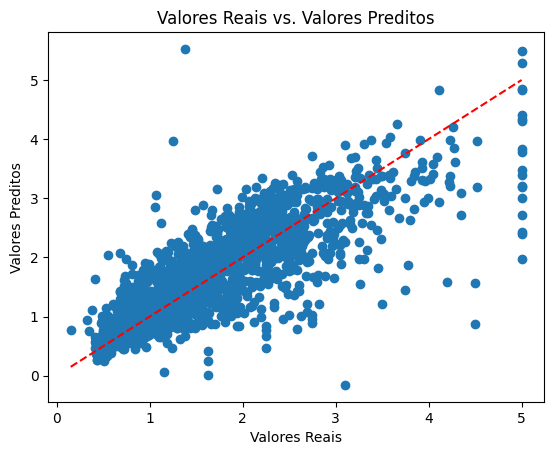

In [18]:
# treinar e avaliar o modelo
history = keras_reg.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    shuffle=True,
    callbacks=[checkpoint_cb, early_stopping_cb]
)

mse_test = keras_reg.score(X_test, y_test)
print("MSE no conjunto de teste:", mse_test)

y_pred = keras_reg.predict(X_test)
plt.scatter(y_test, y_pred)
plt.xlabel("Valores Reais")
plt.ylabel("Valores Preditos")
plt.title("Valores Reais vs. Valores Preditos")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

Qualquer parâmetro extra que passar para o método *fit()* será passado para o modelo Keras subjacente. Repare também que o score será o oposto do MSE, pois a Scikit-Learn quer scores e não perdas (ou seja, os maiores devem ser melhores). Não queremos treinar um único modelo como este, queremos treinar centenas de variantes e ver qual delas apresenta o melhor desempenho no conjunto de validação. Já que existem muitos hiperparâmetros, é preferível usar um randomized search em vez do grid search. 

In [20]:
# treinar e avaliar o modelo usando o randomized search
param_distribs = {
    "model__n_hidden": [0, 1, 2, 3],
    "model__n_neurons": np.arange(1, 100),
    "model__learning_rate": reciprocal(3e-4, 3e-2)
}

rnd_search_cv = RandomizedSearchCV(
    keras_reg,
    param_distribs,
    n_iter=5,
    cv=3
)

rnd_search_cv.fit(
    X_train, y_train, 
    epochs=100, 
    validation_data=(X_val, y_val),
    callbacks=[checkpoint_cb, early_stopping_cb]
)

Epoch 1/100
347/347 ━━━━━━━━━━━━━━━━━━━━ 0s 281us/step - loss: 1.4418 - mean_absolute_error: 1.8886 - val_loss: 0.5937 - val_mean_absolute_error: 0.9953
Epoch 2/100
347/347 ━━━━━━━━━━━━━━━━━━━━ 0s 172us/step - loss: 0.2696 - mean_absolute_error: 0.5701 - val_loss: 0.3460 - val_mean_absolute_error: 0.6750
Epoch 3/100
347/347 ━━━━━━━━━━━━━━━━━━━━ 0s 172us/step - loss: 0.2165 - mean_absolute_error: 0.5079 - val_loss: 0.3143 - val_mean_absolute_error: 0.6333
Epoch 4/100
347/347 ━━━━━━━━━━━━━━━━━━━━ 0s 169us/step - loss: 0.2123 - mean_absolute_error: 0.5015 - val_loss: 0.3122 - val_mean_absolute_error: 0.6304
Epoch 5/100
347/347 ━━━━━━━━━━━━━━━━━━━━ 0s 173us/step - loss: 0.2126 - mean_absolute_error: 0.5031 - val_loss: 0.3047 - val_mean_absolute_error: 0.6215
Epoch 6/100
347/347 ━━━━━━━━━━━━━━━━━━━━ 0s 169us/step - loss: 0.2093 - mean_absolute_error: 0.4968 - val_loss: 0.3036 - val_mean_absolute_error: 0.6200
Epoch 7/100
347/347 ━━━━━━━━━━━━━━━━━━━━ 0s 171us/step - loss: 0.2089 - mean_absol

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KerasRegresso...nput_shape=8 )
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__learning_rate': <scipy.stats....t 0x39bdc7d70>, 'model__n_hidden': [0, 1, ...], 'model__n_neurons': array([ 1, 2..., 97, 98, 99])}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",5
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example<sphx_glr_auto_exampl

O *RandomizedSearchCV* usa a validação cruzada com K-fold, e não os dados reservados para validação no parâmetro *validation_split*, que são utilizadas apenas para as funções de callbacks.

Essa exploração pode durar muito tempo. Uma vez que termine, você poderá acessar os melhores parâmetros encontratos, o melhor score e o modelo Keras treinado.

In [21]:
# encontrar os melhores hiperparâmetros
print("Melhores hiperparâmetros:", rnd_search_cv.best_params_)

# encontrar o melhor score do modelo
print("Melhor score do modelo:", rnd_search_cv.best_score_)

# obter o melhor modelo treinado
best_model = rnd_search_cv.best_estimator_.model

Melhores hiperparâmetros: {'model__learning_rate': 0.009765056043827613, 'model__n_hidden': 3, 'model__n_neurons': 65}
Melhor score do modelo: 0.6726502713942425


Agora, você pode salvar esse modelo, avaliá-lo no conjunto de testes e, se ficar satisfeito com seu desempenho, implementá-lo em produção. Usar o randomized search não é muito difícil e funciona bem para uma série de problemas. Contudo, quando o treinamento é demorado (por exemplo, para problemas mais complexos com conjuntos de dados maiores), essa abordagem explora somente uma pequena parte do espaço do hiperparâmetro. Você pode mitigar esse problema parcialmente, auxiliando no processo de pesquisa de forma manual: primeiro, execute um random search rápido usando intervalos amplos de valores de hiperparâmetros, depois rode outro random search usando intervalos menores de valores centrados nos melhores intervalos encontrados durante a primeira execução e assim por diante. Espera-se que essa abordagem foque um bom conjunto de hiperparâmetros. 

Existem outras técnicas para explorar um espaço de pesquisa com mais eficiência do que de modo aleatório. A ideia é simples: quando se comprova que uma região do espaço é boa, ela deve ser mais explorada. Essas técnicas ampliam as possibilidades e levam a soluções muito melhores em menos tempo. Existem várias bibliotecas Python para que isso que você pode utilizar.

## Conclusão

A importância desse algoritmo é tão grande que vale a pena resumir novamente: para cada instância de treinamento, o algoritmo primeiro faz uma predição (forward pass) e calcula o erro, depois passa por cada camada no sentido inverso a fim de calcular a contribuição do erro de cada conexão e, por fim, ajusta os pesos da conexão para reduzir o erro (etapa do gradiente descendente).